In [ ]:
## 0. Basics

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import loguniform, randint, uniform
from xgboost import XGBClassifier

# Choosing OP & CP (decision based on prior literature)
OP_DAYS = 5
CP_DAYS = 10
SECONDS_PER_DAY = 86400

# Load data
df = pd.read_csv("game_play_data.csv") 

# Ensure proper dtypes
df['time'] = pd.to_numeric(df['time'], errors='coerce')

df.head()

,device,score,time
0,352610060979119,7,1421157320
1,352610060979119,0,1421157288
2,352610060979119,6,1421157344
3,99000072289368,106,1421163166
4,357470044931974,278,1421163783


In [2]:
## 1. Sort by Device & Time
df = df.sort_values(['device', 'time'])

In [3]:
## 2. Compute First Timestamp per Device
first_timestamp = df.groupby('device')['time'].transform('min')
df['days_since_first'] = (df['time'] - first_timestamp) / SECONDS_PER_DAY

In [4]:
## 3. Label OP & CP Events
df['in_OP'] = (df['days_since_first'] >= 0) & (df['days_since_first'] < OP_DAYS)
df['in_CP'] = (df['days_since_first'] >= OP_DAYS) & (df['days_since_first'] < OP_DAYS + CP_DAYS)

In [5]:
## 4: Leak-free Aggregation per Device

# Use ONLY OP events to build features
op_df = df[df['in_OP']].copy()

player_op = (
    op_df
    .groupby('device')
    .agg(
        OP_events=('in_OP', 'sum'),                 # number of OP events
        last_play=('days_since_first', 'max'),      # last OP activity (days since first)
        avg_score=('score', 'mean'),                # average score in OP
    )
    .reset_index()
)

# Use CP events ONLY to define churn label, not for features
cp_df = (
    df[df['in_CP']]
    .groupby('device')
    .agg(
        CP_events=('in_CP', 'sum')                  # number of CP events
    )
    .reset_index()
)

# Merge OP-based features and CP_counts
player = player_op.merge(cp_df, on='device', how='left')

# Devices with no CP activity: CP_events = 0
player['CP_events'] = player['CP_events'].fillna(0).astype(int)

# Drop devices with OP_events == 0 (no observation period activity)
player = player[player['OP_events'] > 0].copy()

In [6]:
## 5. Apply Churn Rule
# churn = 1 if player was active in OP but had no events in CP
player['churn'] = np.where(player['CP_events'] == 0, 1, 0)

# Save player-level dataset for Parts B/C
player.to_csv("player_level_dataset.csv", index=False)

In [7]:
## 6. Export Labeled Dataset
player.to_csv("player_level_dataset.csv", index=False)
player.head()

,device,OP_events,last_play,avg_score,CP_events,churn
0,0,3,0.001319,58.000000,0,1
1,000000000000000,3,0.000741,3.333333,0,1
2,010941525590041,1,0.000000,21.000000,0,1
3,012345678901237,2,0.000602,32.500000,0,1
4,012345678912345,5,0.000544,11.200000,0,1


In [8]:
## 7. Basic Structure

# ===== CONFIG =====
OP_DAYS = 5          # observation period length
CP_DAYS = 10         # prediction period length
CLIP_QUANTILE = 0.99 # for optional winsorization

player = pd.read_csv("player_level_dataset.csv")

print("=== Basic shape ===")
print(player.shape)        # (n_rows, n_cols)
print("\n=== Columns ===")
print(player.dtypes)

print("\n=== First 5 rows ===")
print(player.head())

=== Basic shape ===
(25956, 6)

=== Columns ===
device        object
OP_events      int64
last_play    float64
avg_score    float64
CP_events      int64
churn          int64
dtype: object

=== First 5 rows ===
            device  OP_events  last_play  avg_score  CP_events  churn
0                0          3   0.001319  58.000000          0      1
1  000000000000000          3   0.000741   3.333333          0      1
2  010941525590041          1   0.000000  21.000000          0      1
3  012345678901237          2   0.000602  32.500000          0      1
4  012345678912345          5   0.000544  11.200000          0      1


In [9]:
## 8. Data Quality: Missing, Constants, Duplicates

# 8.1 Missing values
print("\n=== Missing values (count) ===")
print(player.isna().sum())

print("\n=== Missing values (percentage) ===")
print((player.isna().mean() * 100).round(2))

# 8.2 Check duplicates on player id
dup_devices = player['device'].duplicated().sum()
print(f"\nNumber of duplicate device IDs: {dup_devices}")

# 8.3 Constant / near-constant columns
n_unique = player.nunique()
print("\n=== Number of unique values per column ===")
print(n_unique)


=== Missing values (count) ===
device       0
OP_events    0
last_play    0
avg_score    0
CP_events    0
churn        0
dtype: int64

=== Missing values (percentage) ===
device       0.0
OP_events    0.0
last_play    0.0
avg_score    0.0
CP_events    0.0
churn        0.0
dtype: float64

Number of duplicate device IDs: 0

=== Number of unique values per column ===
device       25956
OP_events      139
last_play     6605
avg_score     6793
CP_events       75
churn            2
dtype: int64


In [10]:
## 9. Target Distribution & Basic Descriptives

print("\n=== Churn distribution (counts) ===")
print(player['churn'].value_counts())

print("\n=== Churn distribution (proportions) ===")
print(player['churn'].value_counts(normalize=True))

num_cols = ['OP_events', 'CP_events', 'avg_score', 'last_play']
print("\n=== Descriptive stats for numeric columns ===")
print(player[num_cols + ['churn']].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]))

# Non-negative checks
for col in num_cols:
    neg_share = (player[col] < 0).mean()
    print(f"Share of negative values in {col}: {neg_share:.4f}")


=== Churn distribution (counts) ===
churn
1    24028
0     1928
Name: count, dtype: int64

=== Churn distribution (proportions) ===
churn
1    0.92572
0    0.07428
Name: proportion, dtype: float64

=== Descriptive stats for numeric columns ===
          OP_events     CP_events     avg_score     last_play        churn
count  25956.000000  25956.000000  25956.000000  25956.000000  25956.00000
mean       4.279280      0.491794    232.717963      0.386684      0.92572
std       11.429265      5.210858    489.383619      1.005392      0.26223
min        1.000000      0.000000      0.000000      0.000000      0.00000
1%         1.000000      0.000000      0.000000      0.000000      0.00000
25%        1.000000      0.000000     30.000000      0.000000      1.00000
50%        2.000000      0.000000     82.500000      0.000324      1.00000
75%        3.000000      0.000000    221.000000      0.005639      1.00000
99%       44.450000     10.000000   2290.900000      4.693440      1.00000
max  


=== Group stats by churn (mean / median / std) ===
       OP_events                     avg_score                          \
            mean median        std        mean      median         std   
churn                                                                    
0      15.218361    6.0  29.055456  264.613200  131.955005  447.154357   
1       3.401532    2.0   7.939134  230.158698   78.666667  492.534287   

      last_play                      
           mean    median       std  
churn                                
0      1.748821  1.132645  1.775009  
1      0.277387  0.000116  0.823654  

=== Correlation matrix (raw features + churn) ===
           OP_events  CP_events  avg_score  last_play     churn
OP_events   1.000000   0.403395  -0.039487   0.421171 -0.271123
CP_events   0.403395   1.000000  -0.004081   0.230932 -0.333187
avg_score  -0.039487  -0.004081   1.000000   0.020893 -0.018462
last_play   0.421171   0.230932   0.020893   1.000000 -0.383785
churn      -0.27

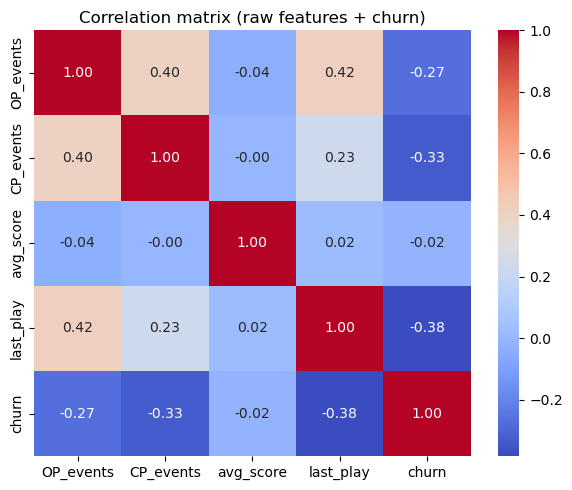

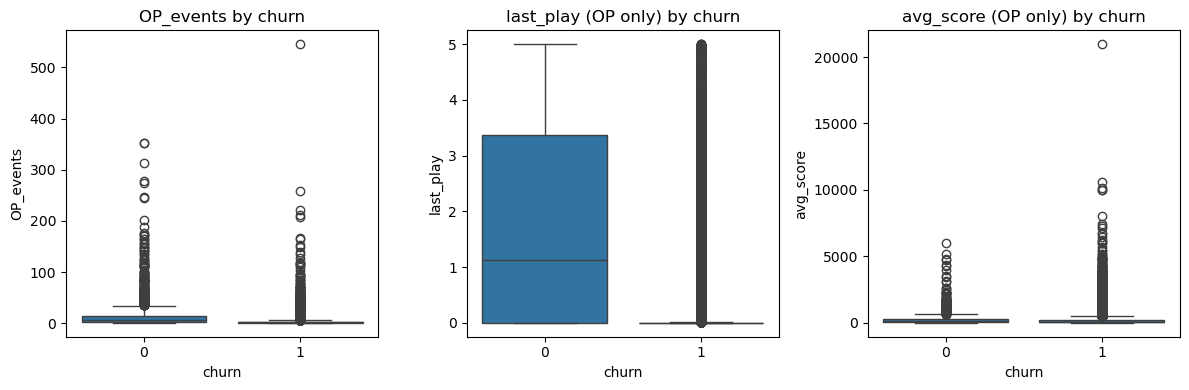

In [11]:
## 10. EDA: Churn VS Non-Churn

print("\n=== Group stats by churn (mean / median / std) ===")
group_stats = (
    player
    .groupby('churn')[['OP_events', 'avg_score', 'last_play']]
    .agg(['mean', 'median', 'std'])
)
print(group_stats)

# Correlation matrix including churn and CP_events (for leakage discussion)
print("\n=== Correlation matrix (raw features + churn) ===")
corr_raw = player[['OP_events', 'CP_events', 'avg_score', 'last_play', 'churn']].corr()
print(corr_raw)

plt.figure(figsize=(6, 5))
sns.heatmap(corr_raw, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix (raw features + churn)")
plt.tight_layout()
plt.show()

# Boxplots by churn
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
sns.boxplot(data=player, x='churn', y='OP_events', ax=axes[0])
axes[0].set_title("OP_events by churn")
sns.boxplot(data=player, x='churn', y='last_play', ax=axes[1])
axes[1].set_title("last_play (OP only) by churn")
sns.boxplot(data=player, x='churn', y='avg_score', ax=axes[2])
axes[2].set_title("avg_score (OP only) by churn")
plt.tight_layout()
plt.show()

In [12]:
## 11. Feature Engineering (OP-BASED ONLY)
# All predictors must be based ONLY on OP features: OP_events, avg_score, last_play.

# 11.1 Total score in OP (volume * performance)
player['total_score'] = player['OP_events'] * player['avg_score']

# 11.2 Heavy user flag: OP_events above 75th percentile
op_q75 = player['OP_events'].quantile(0.75)
player['heavy_user'] = (player['OP_events'] > op_q75).astype(int)

# 11.3 Approximate number of active days in OP
# last_play is max days_since_first within OP, in [0, OP_DAYS)
player['days_active_approx'] = np.floor(player['last_play']) + 1
player['days_active_approx'] = player['days_active_approx'].clip(lower=1, upper=OP_DAYS)

# 11.4 Events per active day (consistency across days)
player['events_per_day'] = player['OP_events'] / player['days_active_approx']

# 11.5 Recency flags within OP
player['active_last_day'] = (player['last_play'] >= (OP_DAYS - 1)).astype(int)
player['active_last_two_days'] = (player['last_play'] >= (OP_DAYS - 2)).astype(int)

print("\n=== Head of engineered features ===")
print(
    player[
        [
            'OP_events',
            'avg_score',
            'last_play',
            'total_score',
            'heavy_user',
            'days_active_approx',
            'events_per_day',
            'active_last_day',
            'active_last_two_days',
        ]
    ].head()
)


=== Head of engineered features ===
   OP_events  avg_score  last_play  total_score  heavy_user  \
0          3  58.000000   0.001319        174.0           0   
1          3   3.333333   0.000741         10.0           0   
2          1  21.000000   0.000000         21.0           0   
3          2  32.500000   0.000602         65.0           0   
4          5  11.200000   0.000544         56.0           1   

   days_active_approx  events_per_day  active_last_day  active_last_two_days  
0                 1.0             3.0                0                     0  
1                 1.0             3.0                0                     0  
2                 1.0             1.0                0                     0  
3                 1.0             2.0                0                     0  
4                 1.0             5.0                0                     0  



=== Descriptive stats for engineered features ===
         total_score    heavy_user  days_active_approx  events_per_day  \
count   25956.000000  25956.000000        25956.000000    25956.000000   
mean      775.014139      0.246995            1.284944        2.930810   
std      2642.650051      0.431272            0.852039        5.947801   
min         0.000000      0.000000            1.000000        0.400000   
25%        53.000000      0.000000            1.000000        1.000000   
50%       183.000000      0.000000            1.000000        1.000000   
75%       610.000000      0.000000            1.000000        3.000000   
max    140802.000000      1.000000            5.000000      545.000000   

       active_last_day  active_last_two_days  
count     25956.000000          25956.000000  
mean          0.025543              0.051241  
std           0.157771              0.220492  
min           0.000000              0.000000  
25%           0.000000              0.000000  


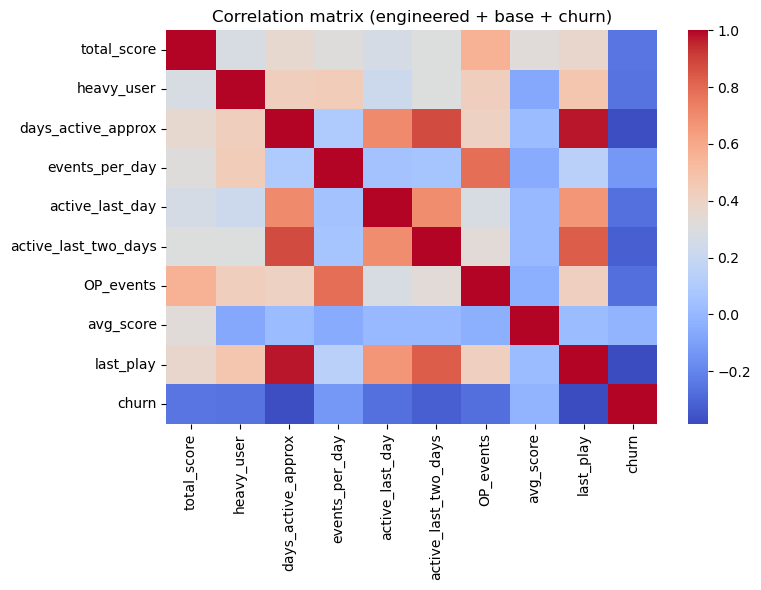


=== Binary engineered features: mean by churn ===
churn                        0         1
heavy_user            0.640560  0.215415
active_last_day       0.174274  0.013609
active_last_two_days  0.302386  0.031089


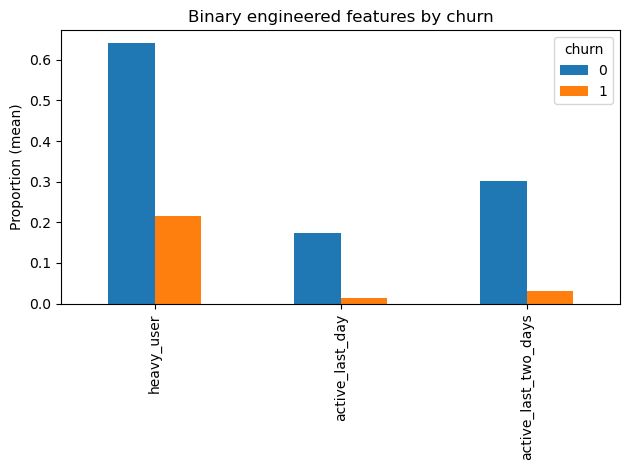

In [13]:
## 12. EDA on Engineered Features

eng_cols = [
    'total_score',
    'heavy_user',
    'days_active_approx',
    'events_per_day',
    'active_last_day',
    'active_last_two_days',
]

print("\n=== Descriptive stats for engineered features ===")
print(player[eng_cols].describe())

print("\n=== Engineered features: mean by churn ===")
print(player.groupby('churn')[eng_cols].mean())

corr_eng = player[
    eng_cols + ['OP_events', 'avg_score', 'last_play', 'churn']
].corr()
print("\n=== Correlation matrix (engineered + base + churn) ===")
print(corr_eng)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_eng, annot=False, cmap="coolwarm")
plt.title("Correlation matrix (engineered + base + churn)")
plt.tight_layout()
plt.show()

# Binary feature barplot
bin_cols = ['heavy_user', 'active_last_day', 'active_last_two_days']
bin_means = player.groupby('churn')[bin_cols].mean().T
print("\n=== Binary engineered features: mean by churn ===")
print(bin_means)

bin_means.plot(kind='bar')
plt.ylabel('Proportion (mean)')
plt.title('Binary engineered features by churn')
plt.tight_layout()
plt.show()

In [14]:
## 13. Outliers & Skew (NO CV LEAKAGE)
# We DO NOT scale or clip using label information.
# To avoid CV leakage, actual scaling will be done in the modeling Pipeline.
# Here we only create monotonic transforms (log1p) to reduce skew.

skew_cols = ['OP_events', 'avg_score', 'last_play', 'total_score']

for col in skew_cols:
    player[f'log_{col}'] = np.log1p(player[col])

print("\n=== Head of log-transformed features ===")
print(player[[f'log_{c}' for c in skew_cols]].head())


=== Head of log-transformed features ===
   log_OP_events  log_avg_score  log_last_play  log_total_score
0       1.386294       4.077537       0.001319         5.164786
1       1.386294       1.466337       0.000740         2.397895
2       0.693147       3.091042       0.000000         3.091042
3       1.098612       3.511545       0.000602         4.189655
4       1.791759       2.501436       0.000544         4.043051


In [15]:
## 14. Final Feature Set (NO LEAKAGE) & Export

feature_cols = [
    # base OP behavioral features
    'OP_events',
    'avg_score',
    'last_play',
    'total_score',

    # engineered behavioral features
    'heavy_user',
    'days_active_approx',
    'events_per_day',
    'active_last_day',
    'active_last_two_days',

    # log-transforms
    'log_OP_events',
    'log_avg_score',
    'log_last_play',
    'log_total_score',
]

X = player[feature_cols]
y = player['churn']

print("\n=== Final feature list ===")
print(feature_cols)

print("\n=== Final modeling dataset (head) ===")
print(player[['device', 'churn'] + feature_cols].head())

# IMPORTANT:
# CP_events is NOT included as a feature (it is used only to define churn).

player_features = player[['device', 'churn'] + feature_cols]
player_features.to_csv("player_features_for_modeling.csv", index=False)

print("\nSaved player_features_for_modeling.csv")


=== Final feature list ===
['OP_events', 'avg_score', 'last_play', 'total_score', 'heavy_user', 'days_active_approx', 'events_per_day', 'active_last_day', 'active_last_two_days', 'log_OP_events', 'log_avg_score', 'log_last_play', 'log_total_score']

=== Final modeling dataset (head) ===
            device  churn  OP_events  avg_score  last_play  total_score  \
0                0      1          3  58.000000   0.001319        174.0   
1  000000000000000      1          3   3.333333   0.000741         10.0   
2  010941525590041      1          1  21.000000   0.000000         21.0   
3  012345678901237      1          2  32.500000   0.000602         65.0   
4  012345678912345      1          5  11.200000   0.000544         56.0   

   heavy_user  days_active_approx  events_per_day  active_last_day  \
0           0                 1.0             3.0                0   
1           0                 1.0             3.0                0   
2           0                 1.0             1.0 

# Modeling

In [ ]:
## 15. Load and Prepare Modeling Data

# Load Data
data = pd.read_csv("player_features_for_modeling.csv")
print(data.columns)

# Divide id, target, feature
id_col = "device"
target_col = "churn"

feature_cols = [c for c in data.columns if c not in [id_col, target_col]]

X = data[feature_cols]
y = data[target_col]

print("\nX shape:", X.shape)
print("y distribution: ", y.value_counts(normalize=True")

Index(['device', 'churn', 'OP_events', 'avg_score', 'last_play', 'total_score',
       'heavy_user', 'days_active_approx', 'events_per_day', 'active_last_day',
       'active_last_two_days', 'log_OP_events', 'log_avg_score',
       'log_last_play', 'log_total_score'],
      dtype='object')

X shape: (25956, 13)
y 값 분포:
churn
1    0.92572
0    0.07428
Name: proportion, dtype: float64


In [ ]:
## 16. Setting the Stratified 5-Fold CV

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
## 17. Logistic Regression (RandomizedSearchCV)

log_reg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # for the class imbalance
        random_state=42
    ))
])

log_reg_param_random = {
    "clf__C": loguniform(1e-3, 1e2),
    "clf__solver": ["lbfgs", "liblinear"]
}

log_reg_random_search = RandomizedSearchCV(
    estimator=log_reg_pipe,
    param_distributions=log_reg_param_random,
    n_iter=20,
    scoring="roc_auc", 
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

log_reg_random_search.fit(X,y)

# save the best parameter for LR
print("best parameter for Logistic Regression:", log_reg_random_search.best_params_)
print("best ROC-AUC(cv) for Logistic Regression:", log_reg_random_search.best_score_)

log_reg_best = log_reg_random_search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits
best parameter for Logistic Regression: {'clf__C': 0.0745934328572655, 'clf__solver': 'lbfgs'}
best ROC-AUC(cv) for Logistic Regression: 0.7981633193536803


In [ ]:
## 18. Random Forest (RandomizedSearchCV)

rf_clf = RandomForestClassifier(
    class_weight="balanced",  # for the class imbalance
    random_state=42,
    n_jobs=-1
)

rf_param_dist = {
    "n_estimators": randint(100, 501),
    "max_depth": randint(3, 21),
    "min_samples_split": randint(2, 11),
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=rf_clf,
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X,y)

# save the best parameter for RF
print("best parameter for Random Forest:", rf_search.best_params_)
print("best ROC-AUC(cv) for Random Forest:", rf_search.best_score_)

rf_best = rf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
best parameter for Random Forest: {'max_depth': 4, 'max_features': 'log2', 'min_samples_leaf': 9, 'min_samples_split': 6, 'n_estimators': 233}
best ROC-AUC(cv) for Random Forest: 0.8000880724934785


In [ ]:
## 19. XGBoost (RandomizedSearchCV)

neg_count = (y == 0).sum()  # non-churn
pos_count = (y == 1).sum()  # churn
scale_pos_weight = neg_count / pos_count

print("neg_count, pos_count, scale_pos_weight:", neg_count, pos_count, scale_pos_weight)

xgb_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

xgb_param_dist = {
    "n_estimators": randint(200, 501),        
    "learning_rate": loguniform(1e-3, 1e-1), 
    "max_depth": randint(3, 11),             
    "subsample": uniform(0.6, 0.4),          
    "colsample_bytree": uniform(0.6, 0.4)   
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=xgb_param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

xgb_search.fit(X, y)

# save the best parameter for XGBoost
print("best parameter for XGBoost:", xgb_search.best_params_)
print("best ROC-AUC(cv) for XGBoost:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_

neg_count, pos_count, scale_pos_weight: 1928 24028 0.080239720326286
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:01:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:01:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:01:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:01:35] WARNING: /Users/runner/miniforge3/conda-bld/xgboo

best parameter for XGBoost: {'colsample_bytree': 0.9400154311159197, 'learning_rate': 0.007923213310872078, 'max_depth': 3, 'n_estimators': 247, 'subsample': 0.7483273008793065}
best ROC-AUC(cv) for XGBoost: 0.7993209021668248


In [ ]:
## 20. Final Best Models

best_models = {
    "logistic_regression": log_reg_best,
    "random_forest": rf_best,
    "xgboost": xgb_best
}

best_models

{'logistic_regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('clf',
                  LogisticRegression(C=0.0745934328572655,
                                     class_weight='balanced', max_iter=1000,
                                     random_state=42))]),
 'random_forest': RandomForestClassifier(class_weight='balanced', max_depth=4,
                        max_features='log2', min_samples_leaf=9,
                        min_samples_split=6, n_estimators=233, n_jobs=-1,
                        random_state=42),
 'xgboost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9400154311159197, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric='logloss', feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constrai

# Evaluation

In [75]:
## 21. Import Evaluation Tools and Initialize Metric Dictionaries

from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
importances_dict = {}

metrics_dict = {
    "Model": [],
    "ROC-AUC": [],
    "F1": [],
    "Accuracy": []
}

In [77]:
## 22. Evaluate Models with 5-fold CV, Compute Metrics, and Extract Feature Importances

for model_name, model in best_models.items():
    print(f"\nEvaluating model: {model_name}")
    
    # Stratified 5-Fold CV predictions (probabilities)
    y_pred_prob = cross_val_predict(
        model, X, y, cv=cv, method='predict_proba', n_jobs=-1
    )[:,1]  # probability of class 1 (churn)
    
    # Binary predictions (threshold 0.5)
    y_pred = (y_pred_prob >= 0.5).astype(int)
    
    # Compute metrics
    roc = roc_auc_score(y, y_pred_prob)
    f1 = f1_score(y, y_pred)
    acc = accuracy_score(y, y_pred)
    
    metrics_dict["Model"].append(model_name)
    metrics_dict["ROC-AUC"].append(roc)
    metrics_dict["F1"].append(f1)
    metrics_dict["Accuracy"].append(acc)
    
    print(f"ROC-AUC: {roc:.4f}, F1: {f1:.4f}, Accuracy: {acc:.4f}")
    
    # Feature importance extraction
    if model_name == "logistic_regression":
        importances = pd.Series(model.named_steps['clf'].coef_[0], index=feature_cols)
    elif model_name in ["random_forest", "xgboost"]:
        importances = pd.Series(model.feature_importances_, index=feature_cols)
    
    importances_dict[model_name] = importances.sort_values(ascending=False)

# Convert metrics to DataFrame
metrics_df = pd.DataFrame(metrics_dict)
print("\n=== Model Performance Comparison ===")
print(metrics_df)


Evaluating model: logistic_regression
ROC-AUC: 0.7978, F1: 0.8939, Accuracy: 0.8175

Evaluating model: random_forest
ROC-AUC: 0.7984, F1: 0.8844, Accuracy: 0.8031

Evaluating model: xgboost


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:25:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:25:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:25:10] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1763746887906/work/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [19:25:11] WARNING: /Users/runner/miniforge3/conda-bld/xgboo

ROC-AUC: 0.7976, F1: 0.8815, Accuracy: 0.7987

=== Model Performance Comparison ===
                 Model   ROC-AUC        F1  Accuracy
0  logistic_regression  0.797837  0.893930  0.817499
1        random_forest  0.798375  0.884433  0.803051
2              xgboost  0.797611  0.881513  0.798659


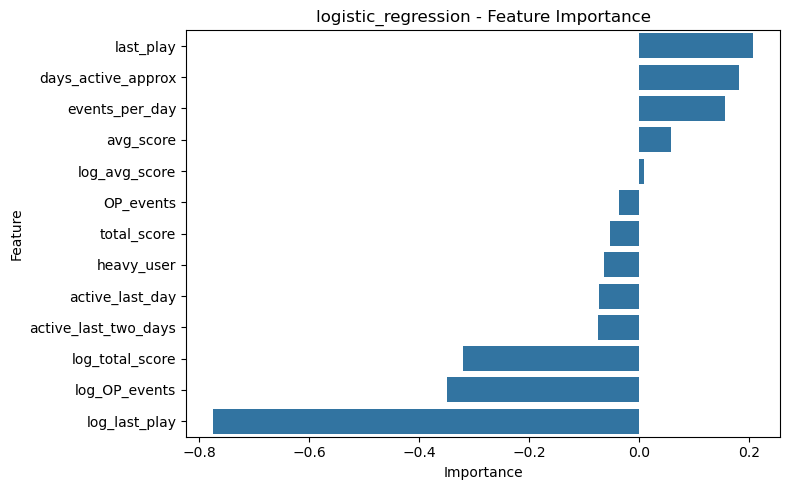

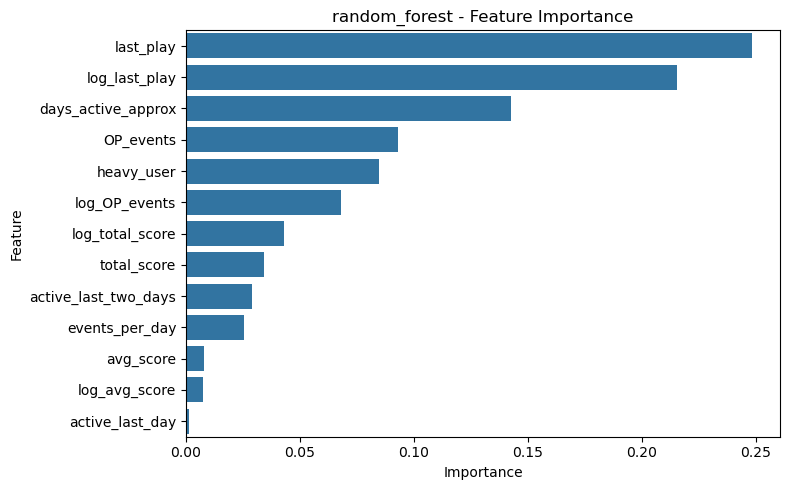

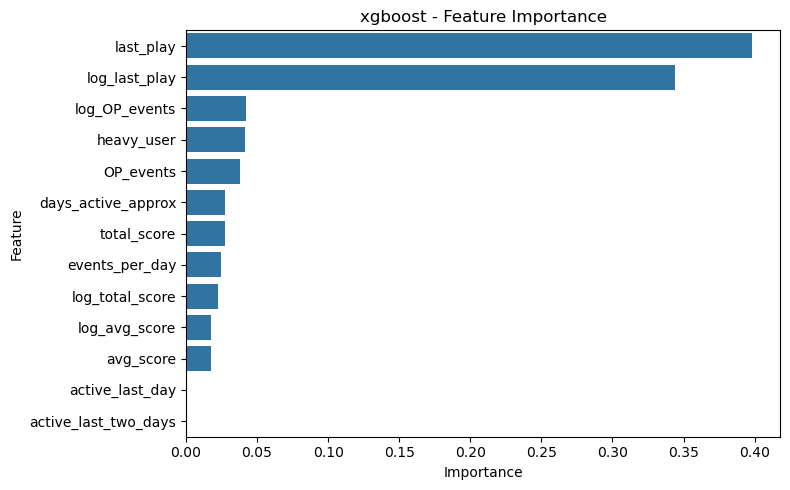

In [79]:
## 23. Feature Importance Visualization

import matplotlib.pyplot as plt
import seaborn as sns

for model_name, importances in importances_dict.items():
    plt.figure(figsize=(8,5))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"{model_name} - Feature Importance")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

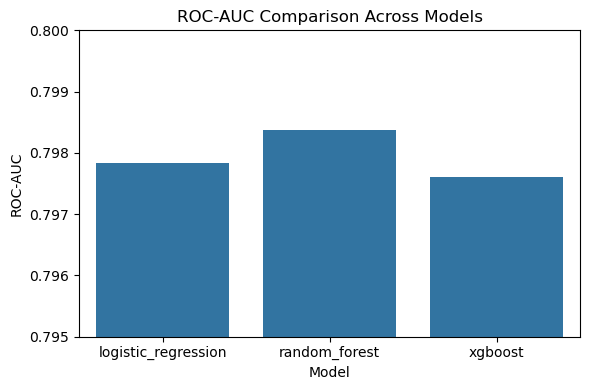

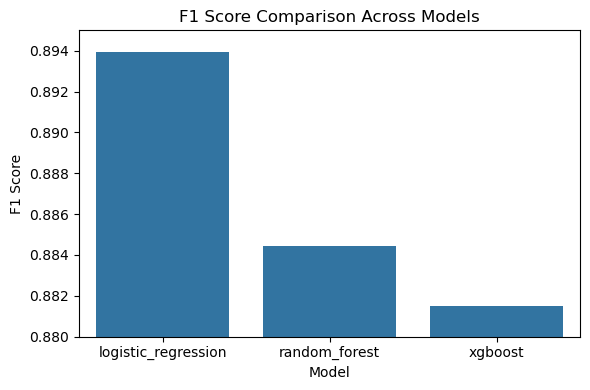

In [93]:
## 24. Summary Plots for Model Comparison

# ROC-AUC comparison barplot
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='ROC-AUC', data=metrics_df)
plt.title("ROC-AUC Comparison Across Models")
plt.ylabel("ROC-AUC")
plt.ylim(0.795, 0.8)
plt.tight_layout()
plt.show()

# F1 score comparison barplot
plt.figure(figsize=(6,4))
sns.barplot(x='Model', y='F1', data=metrics_df)
plt.title("F1 Score Comparison Across Models")
plt.ylabel("F1 Score")
plt.ylim(0.88, 0.895)
plt.tight_layout()
plt.show()